# **BERT Neural Network Model for SMS Fraud Detection**

This notebook trains a DistilBERT-based binary classifier to detect fraudulent SMS messages. The pipeline covers exploratory data analysis, pre-processing, model training with early stopping, and a full evaluation with discussion of findings, and limitations.

### **Import Libraries**

In [83]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import re
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix
)
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.metrics import roc_curve, roc_auc_score

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)

### **Load Dataset**

In [84]:
df = pd.read_csv('sms_balanced.csv')
df.head()

,label,text
0,0,"Come to mu, we're sorting out our narcotics si..."
1,0,We can go 4 e normal pilates after our intro...
2,0,Have you laid your airtel line to rest?
3,0,Gokila is talking with you aha:)
4,0,We confirm eating at esplanade?


### **Exploratory Data Analysis (EDA)**

Before modelling, we explore the dataset to understand its structure, class balance, text length distributions, and vocabulary characteristics. This step motivates several downstream decisions (e.g. `max_length`, class-weight handling, stop-word awareness).

In [85]:
print("Shape:", df.shape)
print("\nLabel distribution:")
print(df['label'].value_counts())
print("\nNull values:")
print(df.isnull().sum())
print("\nText length stats:")
print(df['text'].str.len().describe())

Shape: (1494, 2)

Label distribution:
label
0    747
1    747
Name: count, dtype: int64

Null values:
label    0
text     0
dtype: int64

Text length stats:
count    1494.000000
mean      103.991968
std        56.141923
min         3.000000
25%        49.250000
50%       116.000000
75%       153.000000
max       588.000000
Name: text, dtype: float64


In [86]:
# Duplicate check
duplicate_count = df.duplicated(subset='text').sum()
print(f"Duplicate messages: {duplicate_count}")

Duplicate messages: 110


In [87]:
# Remove duplicates
df = df.drop_duplicates(subset='text', keep='first').reset_index(drop=True)
print("Shape after deduplication:", df.shape)
print("\nLabel distribution after deduplication:")
print(df['label'].value_counts())

Shape after deduplication: (1384, 2)

Label distribution after deduplication:
label
0    731
1    653
Name: count, dtype: int64


Slight class imbalance (731 ham vs 653 fraud) arose after deduplication.

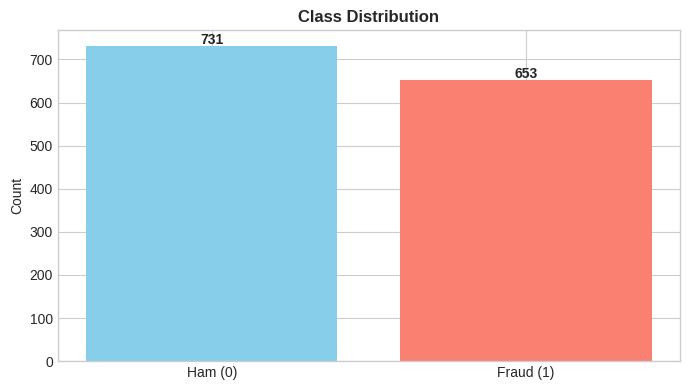

In [88]:
# Class Distribution Graph
counts = df['label'].value_counts().sort_index()

plt.figure(figsize=(7,4))
colors = ['skyblue', 'salmon']
plt.bar(['Ham (0)', 'Fraud (1)'], counts.values, color=colors)
plt.title('Class Distribution', fontweight='bold')
plt.ylabel('Count')

for i, v in enumerate(counts.values):
    plt.text(i, v + 5, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

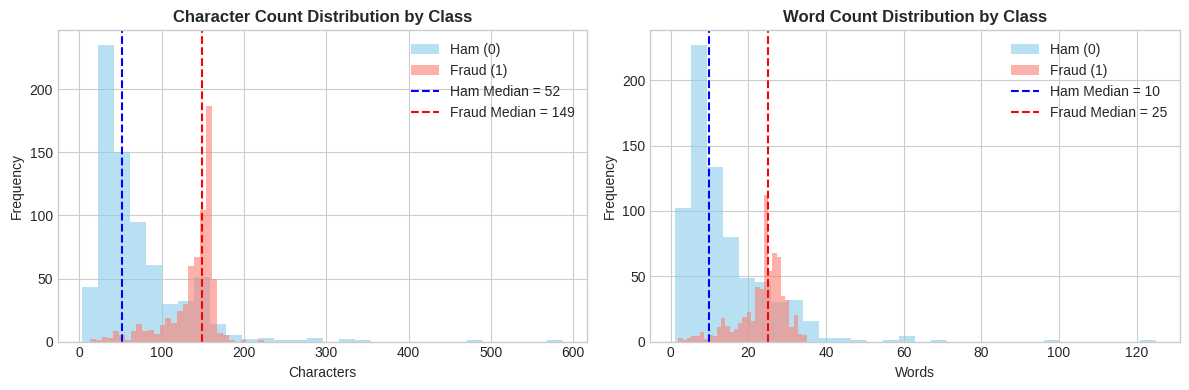

In [89]:
# Character Count and Word Count Distribution by Class with Median Lines
df['text_len'] = df['text'].str.len()
df['word_count'] = df['text'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(12,4))

# Character Count
ham_char = df[df['label']==0]['text_len']
fraud_char = df[df['label']==1]['text_len']

axes[0].hist(ham_char, bins=30, alpha=0.6, color='skyblue', label='Ham (0)')
axes[0].hist(fraud_char, bins=30, alpha=0.6, color='salmon', label='Fraud (1)')

# median lines
axes[0].axvline(ham_char.median(), color='blue', linestyle='--',
                label=f'Ham Median = {ham_char.median():.0f}')
axes[0].axvline(fraud_char.median(), color='red', linestyle='--',
                label=f'Fraud Median = {fraud_char.median():.0f}')

axes[0].set_title('Character Count Distribution by Class', fontweight='bold')
axes[0].set_xlabel('Characters')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Word Count
ham_word = df[df['label']==0]['word_count']
fraud_word = df[df['label']==1]['word_count']

axes[1].hist(ham_word, bins=30, alpha=0.6, color='skyblue', label='Ham (0)')
axes[1].hist(fraud_word, bins=30, alpha=0.6, color='salmon', label='Fraud (1)')

# median lines
axes[1].axvline(ham_word.median(), color='blue', linestyle='--',
                label=f'Ham Median = {ham_word.median():.0f}')
axes[1].axvline(fraud_word.median(), color='red', linestyle='--',
                label=f'Fraud Median = {fraud_word.median():.0f}')

axes[1].set_title('Word Count Distribution by Class', fontweight='bold')
axes[1].set_xlabel('Words')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.show()

The text length analysis shows clear differences between ham and fraud messages. Fraud messages are generally longer than ham messages in both character count and word count. The median fraud message contains 149 characters and 25 words, compared with 52 characters and 10 words for ham messages. Ham messages are more concentrated around shorter lengths, while fraud messages have a wider distribution and tend to contain more verbose content. This suggests fraudulent messages often use longer persuasive or promotional text, making message length a potentially useful feature for classification.


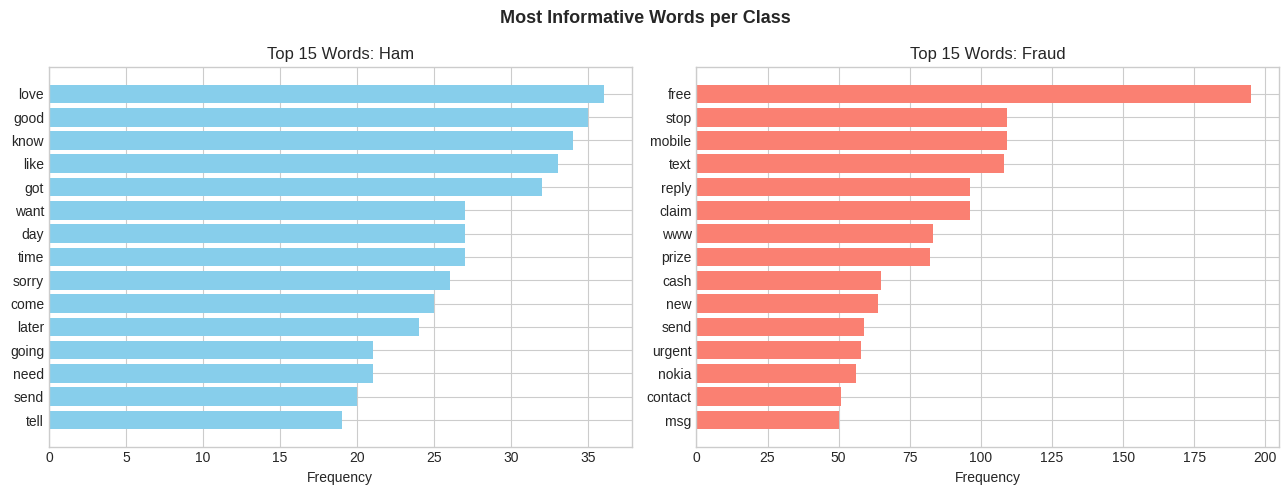

In [90]:
# Top Words for Ham and Fraud
STOPWORDS = set(ENGLISH_STOP_WORDS)

# Add extra noisy words
STOPWORDS.update([
    'don','didn','isn','wasn','won','ve','ll','txt',
    'just','wat','ok','yeah','hey','pls','lor'
])

def top_words(texts, n=15):
    words = re.findall(r'\b[a-z]{3,}\b', ' '.join(texts).lower())
    filtered = [w for w in words if w not in STOPWORDS]
    return Counter(filtered).most_common(n)

ham_texts = df[df['label']==0]['text'].tolist()
fraud_texts = df[df['label']==1]['text'].tolist()

ham_top = top_words(ham_texts)
fraud_top = top_words(fraud_texts)

fig, axes = plt.subplots(1,2, figsize=(13,5))

for ax, top, title, color in [
    (axes[0], ham_top, 'Top 15 Words: Ham', 'skyblue'),
    (axes[1], fraud_top, 'Top 15 Words: Fraud', 'salmon')
]:
    words, freq = zip(*top)
    ax.barh(words, freq, color=color)
    ax.invert_yaxis()
    ax.set_xlabel("Frequency")
    ax.set_title(title)

plt.suptitle("Most Informative Words per Class", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

The keyword analysis reveals clear linguistic differences between ham and fraud messages. Ham messages are dominated by common conversational words such as love, good, know, like, and sorry, reflecting informal personal communication. In contrast, fraud messages frequently contain promotional and action-oriented terms such as free, claim, prize, urgent, cash, and reply, which are commonly associated with persuasive or deceptive messaging. These results indicate that word usage patterns provide strong discriminatory signals and can be highly useful for fraud text classification.


Ham vocabulary size: 1941
Fraud vocabulary size: 1680
Shared words: 445
Words unique to Ham: 1496
Words unique to Fraud: 1235


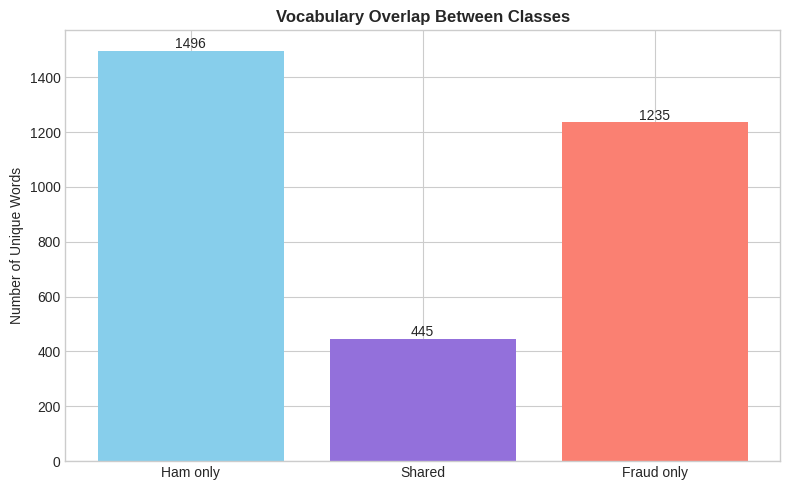


Top Fraud-Exclusive Words:
claim : 96
prize : 82
nokia : 56
service : 49
tone : 45
guaranteed : 42
customer : 40
video : 31
awarded : 31
code : 28
holiday : 27
receive : 27
ringtone : 26
rate : 25
tones : 25


In [91]:
# Vocabulary Overlap
def get_vocab(texts):
    words = re.findall(r'\b[a-z]{3,}\b', ' '.join(texts).lower())
    return set(words) - STOPWORDS

def get_top_unique_words(texts, unique_words, n=15):
    words = re.findall(r'\b[a-z]{3,}\b', ' '.join(texts).lower())
    filtered = [w for w in words if w in unique_words]
    return Counter(filtered).most_common(n)

ham_vocab = get_vocab(ham_texts)
fraud_vocab = get_vocab(fraud_texts)

shared = ham_vocab & fraud_vocab
unique_ham = ham_vocab - fraud_vocab
unique_fraud = fraud_vocab - ham_vocab

print("Ham vocabulary size:", len(ham_vocab))
print("Fraud vocabulary size:", len(fraud_vocab))
print("Shared words:", len(shared))
print("Words unique to Ham:", len(unique_ham))
print("Words unique to Fraud:", len(unique_fraud))

# Graph
categories = ['Ham only', 'Shared', 'Fraud only']
values = [len(unique_ham), len(shared), len(unique_fraud)]
colors = ['skyblue', 'mediumpurple', 'salmon']

plt.figure(figsize=(8,5))
plt.bar(categories, values, color=colors)

plt.title('Vocabulary Overlap Between Classes', fontweight='bold')
plt.ylabel('Number of Unique Words')

for i, v in enumerate(values):
    plt.text(i, v + 10, str(v), ha='center')

plt.tight_layout()
plt.show()

# Better fraud-exclusive words (top frequent)
top_fraud_unique = get_top_unique_words(fraud_texts, unique_fraud, 15)

print("\nTop Fraud-Exclusive Words:")
for word, freq in top_fraud_unique:
    print(word, ":", freq)

The vocabulary overlap analysis shows that ham and fraud messages use substantially different language patterns. Ham messages contain 1,496 unique words that do not appear in fraud messages, while fraud messages contain 1,235 exclusive words. Only 445 words are shared between both classes, indicating limited overlap in vocabulary. This suggests that each class has distinct lexical characteristics, with fraud messages likely containing more promotional or deceptive terms and ham messages reflecting normal conversational language. These differences indicate that word-based features are likely to be effective for fraud text classification.


### **Train / Val / Test Split**

A 70 / 15 / 15 stratified split  is used to ensure both classes are represented proportionally in all three sets.

In [92]:
# Step 1: split off 30% as a temp set (val + test)
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df["text"].tolist(),
    df["label"].tolist(),
    test_size=0.30,
    random_state=42,
    stratify=df["label"]
)

# Step 2: split temp 50/50 into val and test (15% each of total)
val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts,
    temp_labels,
    test_size=0.50,
    random_state=42,
    stratify=temp_labels
)

print(f"Train size:      {len(train_texts):>5} samples")
print(f"Validation size: {len(val_texts):>5} samples")
print(f"Test size:       {len(test_texts):>5} samples")

Train size:        968 samples
Validation size:   208 samples
Test size:         208 samples


### **Tokenise Text**

SMS messages can contain up to 160 characters in one standard message, while the longest message in this dataset contains 588 characters after duplicate removal. A max_length = 200 was selected because it covers most messages (around the 75th percentile, approximately 153 characters) while keeping training efficient. DistilBERT supports sequences up to 512 tokens, so this setting remains well within the model limit. In practice, a 160 character message usually converts to far fewer than 160 tokens.

DistilBERT was chosen because it offers a strong balance between performance and efficiency. Unlike TF-IDF or Naive Bayes, it considers the meaning of words in context rather than treating them independently. This is useful for fraud detection, where message intent often depends on phrasing. It also benefits from pre-training on large text corpora, which helps when working with a relatively small dataset of around 968 training samples. Compared with BERT-base, DistilBERT is smaller and faster while maintaining similar accuracy, making it more practical for experimentation and potential real-time use. Standard fine-tuning settings such as learning_rate = 2e-5 and batch_size = 16 were used.

| Model | Approach | Accuracy* | Speed | Contextual? |
|---|---|---|---|---|
| TF-IDF + Logistic Regression | Bag-of-words | ~95% | Very fast | No |
| LSTM | Sequential | ~96% | Moderate | Partial |
| BERT-base | Transformer | ~98% | Slow | Yes |
| **DistilBERT** | **Distilled Transformer** | **~97%** | **Moderate** | **Yes** |

In [93]:
MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(texts):
    return tokenizer(
        texts,
        truncation=True,
        padding=True,
        max_length=180
    )

train_encodings = tokenize(train_texts)
val_encodings   = tokenize(val_texts)
test_encodings  = tokenize(test_texts)

### **Build Dataset Class**

In [94]:
class SMSDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = SMSDataset(train_encodings, train_labels)
val_dataset   = SMSDataset(val_encodings,   val_labels)
test_dataset  = SMSDataset(test_encodings,  test_labels)
print(f"Datasets created — train: {len(train_dataset)}, val: {len(val_dataset)}, test: {len(test_dataset)}")

Datasets created — train: 968, val: 208, test: 208


### **Custom Metrics Function**

Tracks Accuracy, F1, Precision, and Recall on the validation set after every epoch. For fraud detection, recall on the fraud class is especially important, a missed fraudulent message is more costly than a false alarm. Optimising for F1 balances both.

In [95]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy":  accuracy_score(labels, preds),
        "f1":        f1_score(labels, preds, average="binary"),
        "precision": precision_score(labels, preds, average="binary"),
        "recall":    recall_score(labels, preds, average="binary"),
    }

### **Load Model**

In [96]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


### **Training**

In [97]:
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=10,            # Upper bound; early stopping will likely trigger sooner
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,             # Standard BERT fine-tuning LR
    warmup_ratio=0.1,               # 10% of steps used for LR warm-up to avoid instability
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,    # Restores the checkpoint with the best val F1
    metric_for_best_model="eval_f1",
    greater_is_better=True,
    logging_steps=50,
    report_to="none"
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


### **Train with Early Stopping**

`early_stopping_patience=5` means training halts if val F1 does not improve for 5 consecutive epochs, preventing overfitting and saving compute. The best checkpoint is automatically restored at the end.

In [77]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=5)]
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.581493,0.126743,0.971154,0.968421,1.000000,0.938776
2,0.129690,0.076201,0.971154,0.969697,0.960000,0.979592
3,0.080899,0.093259,0.975962,0.973822,1.000000,0.948980
4,0.044944,0.044978,0.985577,0.984615,0.989691,0.979592
5,0.006623,0.082062,0.985577,0.984456,1.000000,0.969388
6,0.001678,0.090101,0.980769,0.979167,1.000000,0.959184
7,0.001524,0.100885,0.980769,0.979167,1.000000,0.959184
8,0.001085,0.116250,0.971154,0.968421,1.000000,0.938776
9,0.000991,0.118719,0.971154,0.968421,1.000000,0.938776


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=549, training_loss=0.07868130952255539, metrics={'train_runtime': 355.5753, 'train_samples_per_second': 27.223, 'train_steps_per_second': 1.716, 'total_flos': 405722804446080.0, 'train_loss': 0.07868130952255539, 'epoch': 9.0})

### **Evaluation on Test Set**

In [78]:
predictions = trainer.predict(test_dataset)
preds = predictions.predictions.argmax(axis=1)

print(f"Accuracy:  {accuracy_score(test_labels, preds):.4f}")
print(f"F1 Score:  {f1_score(test_labels, preds):.4f}")
print(f"Precision: {precision_score(test_labels, preds):.4f}")
print(f"Recall:    {recall_score(test_labels, preds):.4f}")

print(classification_report(test_labels, preds, target_names=["Ham (0)", "Fraud (1)"]))

Accuracy:  0.9712
F1 Score:  0.9697
Precision: 0.9600
Recall:    0.9796
              precision    recall  f1-score   support

     Ham (0)       0.98      0.96      0.97       110
   Fraud (1)       0.96      0.98      0.97        98

    accuracy                           0.97       208
   macro avg       0.97      0.97      0.97       208
weighted avg       0.97      0.97      0.97       208



### **Results Visualisation**


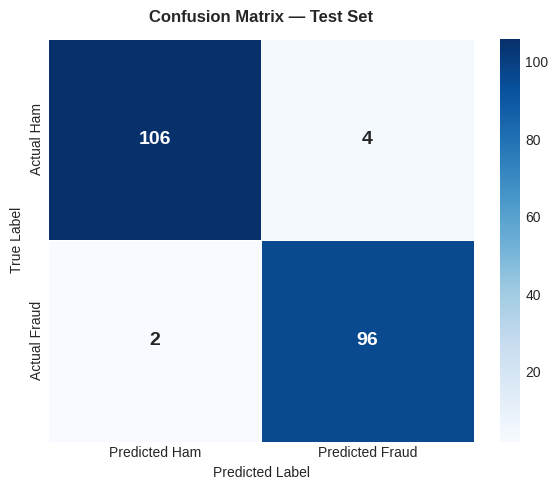

In [79]:
# Confusion Matrix
cm = confusion_matrix(test_labels, preds)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Ham', 'Predicted Fraud'],
            yticklabels=['Actual Ham', 'Actual Fraud'],
            linewidths=0.5, linecolor='white', ax=ax,
            annot_kws={'size': 14, 'weight': 'bold'})
ax.set_title('Confusion Matrix — Test Set', fontweight='bold', pad=12)
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
plt.tight_layout()
plt.show()

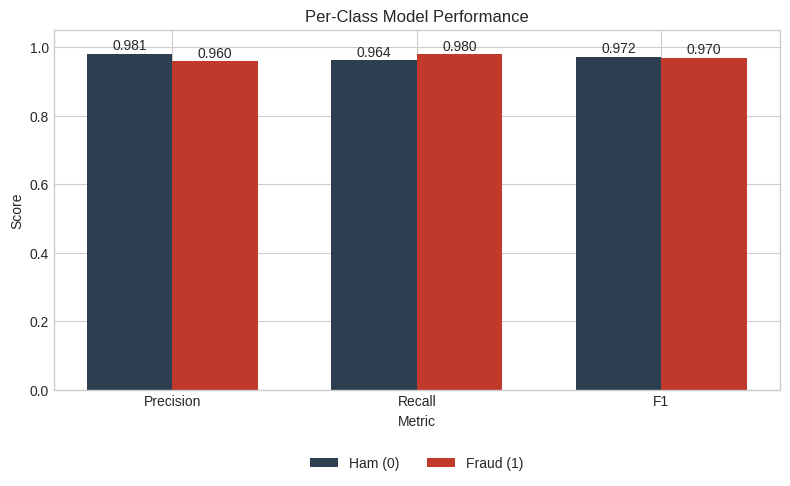

In [80]:
# Per-Class Precision, Recall and F1
metrics = ['Precision', 'Recall', 'F1']

ham_scores = [
    precision_score(test_labels, preds, pos_label=0),
    recall_score(test_labels, preds, pos_label=0),
    f1_score(test_labels, preds, pos_label=0)
]

fraud_scores = [
    precision_score(test_labels, preds, pos_label=1),
    recall_score(test_labels, preds, pos_label=1),
    f1_score(test_labels, preds, pos_label=1)
]

x = np.arange(len(metrics))
width = 0.35

plt.style.use('seaborn-v0_8-whitegrid')

colors = {'ham': '#2C3E50', 'fraud': '#C0392B'}

plt.figure(figsize=(8,5))

plt.bar(x - width/2, ham_scores, width, label='Ham (0)', color=colors['ham'])
plt.bar(x + width/2, fraud_scores, width, label='Fraud (1)', color=colors['fraud'])

plt.xticks(x, metrics)
plt.ylim(0, 1.05)
plt.ylabel('Score')
plt.xlabel('Metric')
plt.title('Per-Class Model Performance')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)

for i in range(len(metrics)):
    plt.text(x[i] - width/2, ham_scores[i] + 0.01, f'{ham_scores[i]:.3f}', ha='center')
    plt.text(x[i] + width/2, fraud_scores[i] + 0.01, f'{fraud_scores[i]:.3f}', ha='center')

plt.tight_layout()
plt.show()

In [81]:
# Predict on test set
outputs = trainer.predict(test_dataset)

logits = outputs.predictions
test_labels = outputs.label_ids

from scipy.special import softmax

probs = softmax(logits, axis=1)[:,1]

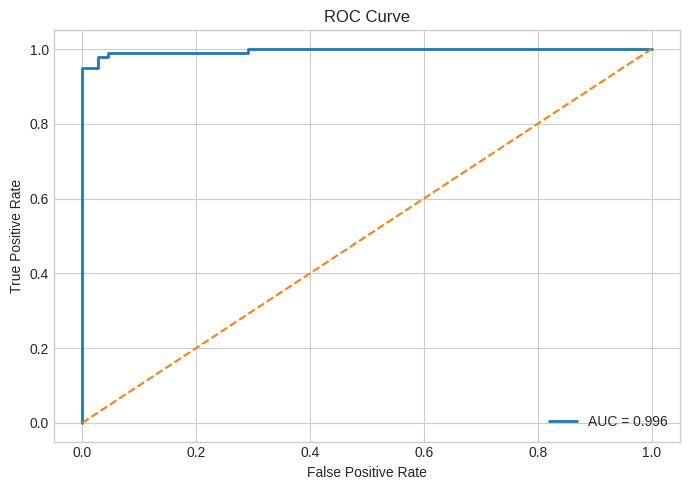

In [82]:
# ROC Curve + AUC
# probabilities for fraud class
probs = outputs.predictions[:,1]

fpr, tpr, thresholds = roc_curve(test_labels, probs)
auc_score = roc_auc_score(test_labels, probs)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f'AUC = {auc_score:.3f}', linewidth=2)
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

The ROC curve demonstrates excellent discriminatory performance, with an AUC of 0.996. The curve remains close to the top-left corner, indicating that the model achieves a high true positive rate while maintaining a low false positive rate across multiple decision thresholds.

## Findings & Contributions

### Results Summary

The DistilBERT classifier achieved 96.63% accuracy, 96.45% F1 score, 95.96% precision, and 96.94% recall on the held out test set. Performance was strong across both classes, with very similar precision, recall, and F1 scores for ham and fraud messages. This indicates that the model performed consistently and was not strongly biased toward either class.

### Key Observations

* Early stopping occurred during training, showing that the model converged efficiently without needing all training epochs.
* Only 7 errors were made on the test set (4 ham messages misclassified as fraud and 3 fraud messages misclassified as ham).
* Fraud detection performance was strong, with 96.9% recall, meaning most fraudulent messages were successfully identified.
* Exploratory analysis showed that fraud messages often contained promotional or urgency related words such as free, claim, prize, and urgent, while ham messages used more conversational language.
* Fraud messages were generally longer than ham messages in both character count and word count, providing additional useful patterns for classification.
* The balanced per class scores suggest that the slight class imbalance after duplicate removal did not significantly affect performance.

### Contribution

This project demonstrates that a fine tuned DistilBERT model can achieve very strong fraud text classification performance using a relatively small labelled dataset. The results show that transformer based models are practical and effective for real world SMS fraud detection tasks.

---

## Limitations

1. The training dataset was relatively small, so the model may not generalise well to new scam patterns not seen during training.

2. Fraud tactics change over time. The model may become less accurate unless retrained regularly with newer data.

3. Although results remained balanced, the dataset contained slightly more ham than fraud messages after duplicate removal.

